In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
state_cases = pd.read_csv("us_county_confirmed_cases.csv")
state_deaths = pd.read_csv("us_county_confirmed_deaths.csv")

state_cases = state_cases.drop(columns=['COUNTY', 'NAME', 'POP70', 'HHD70', 'POP80', 'HHD80', 'POP90', 'HHD90',
       'POP00', 'HHD00', 'POP10', 'HHD10', 'countyFIPS', 'County Name', 'State', 'StateFIPS'])
state_deaths = state_deaths.drop(columns=['COUNTY', 'NAME', 'POP70', 'HHD70', 'POP80', 'HHD80', 'POP90', 'HHD90',
       'POP00', 'HHD00','POP10', 'HHD10', 'countyFIPS', 'County Name', 'State', 'StateFIPS'])

In [3]:
case_county = pd.DataFrame(state_cases)
len(case_county)
case_county['2022/9/1']

0       18125.0
1       64672.0
2        6757.0
3        7394.0
4       16597.0
         ...   
3138    12063.0
3139    11526.0
3140     6061.0
3141     2631.0
3142     1790.0
Name: 2022/9/1, Length: 3143, dtype: float64

### how many 0 in that day

In [4]:
for col in list(case_county.columns):
    zero = len(case_county[case_county[col] == 0])
    pct_zero_c = zero/len(case_county)
    
    # need to define drop dates with how many 0
    if pct_zero_c > 0.2:
        print(col)
        case_county.drop(columns= col,inplace = True)

2020/1/22
2020/1/23
2020/1/24
2020/1/25
2020/1/26
2020/1/27
2020/1/28
2020/1/29
2020/1/30
2020/1/31
2020/2/1
2020/2/2
2020/2/3
2020/2/4
2020/2/5
2020/2/6
2020/2/7
2020/2/8
2020/2/9
2020/2/10
2020/2/11
2020/2/12
2020/2/13
2020/2/14
2020/2/15
2020/2/16
2020/2/17
2020/2/18
2020/2/19
2020/2/20
2020/2/21
2020/2/22
2020/2/23
2020/2/24
2020/2/25
2020/2/26
2020/2/27
2020/2/28
2020/2/29
2020/3/1
2020/3/2
2020/3/3
2020/3/4
2020/3/5
2020/3/6
2020/3/7
2020/3/8
2020/3/9
2020/3/10
2020/3/11
2020/3/12
2020/3/13
2020/3/14
2020/3/15
2020/3/16
2020/3/17
2020/3/18
2020/3/19
2020/3/20
2020/3/21
2020/3/22
2020/3/23
2020/3/24
2020/3/25
2020/3/26
2020/3/27
2020/3/28
2020/3/29
2020/3/30
2020/3/31
2020/4/1
2020/4/2
2020/4/3
2020/4/4
2020/4/5
2020/4/6


In [5]:
case_county

,2020/4/7,2020/4/8,2020/4/9,2020/4/10,2020/4/11,2020/4/12,2020/4/13,2020/4/14,2020/4/15,2020/4/16,...,2023/4/8,2023/4/9,2023/4/10,2023/4/11,2023/4/12,2023/4/13,2023/4/14,2023/4/15,2023/4/16,2023/4/17
0,12.0,12.0,17.0,17.0,19.0,19.0,19.0,23.0,25.0,25.0,...,19857.0,19857.0,19857.0,19857.0,19857.0,19873.0,19873.0,19873.0,19873.0,19873.0
1,42.0,49.0,59.0,59.0,66.0,71.0,78.0,87.0,98.0,102.0,...,70248.0,70248.0,70248.0,70248.0,70248.0,70299.0,70299.0,70299.0,70299.0,70299.0
2,3.0,3.0,7.0,9.0,10.0,10.0,10.0,11.0,13.0,14.0,...,7520.0,7520.0,7520.0,7520.0,7520.0,7553.0,7553.0,7553.0,7553.0,7553.0
3,8.0,9.0,11.0,11.0,13.0,16.0,17.0,17.0,19.0,23.0,...,8119.0,8119.0,8119.0,8119.0,8119.0,8122.0,8122.0,8122.0,8122.0,8122.0
4,10.0,10.0,11.0,12.0,12.0,13.0,15.0,16.0,17.0,18.0,...,18800.0,18800.0,18800.0,18800.0,18800.0,18817.0,18817.0,18817.0,18817.0,18817.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3138,6.0,6.0,6.0,7.0,7.0,7.0,9.0,9.0,10.0,10.0,...,12527.0,12527.0,12527.0,12527.0,12527.0,12527.0,12532.0,12532.0,12532.0,12532.0
3139,44.0,45.0,50.0,53.0,53.0,56.0,56.0,57.0,59.0,59.0,...,12156.0,12156.0,12156.0,12156.0,12156.0,12156.0,12161.0,12161.0,12161.0,12161.0
3140,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,6426.0,6426.0,6426.0,6426.0,6426.0,6426.0,6427.0,6427.0,6427.0,6427.0
3141,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,2702.0,2702.0,2702.0,2702.0,2702.0,2702.0,2702.0,2702.0,2702.0,2702.0


In [6]:
all_cases = pd.DataFrame({'sum': state_cases.sum(axis=0)})
# get daily
all_cases['daily'] = (
    all_cases['sum'].transform(lambda s: s.sub(s.shift().fillna(0)).abs())
)
all_cases = all_cases.tail(-1)

all_deaths = pd.DataFrame({'sum': state_deaths.sum(axis=0)})
# get daily
all_deaths['daily'] = (
    all_deaths['sum'].transform(lambda s: s.sub(s.shift().fillna(0)).abs())
)
all_deaths = all_deaths.tail(-1)

<AxesSubplot: >

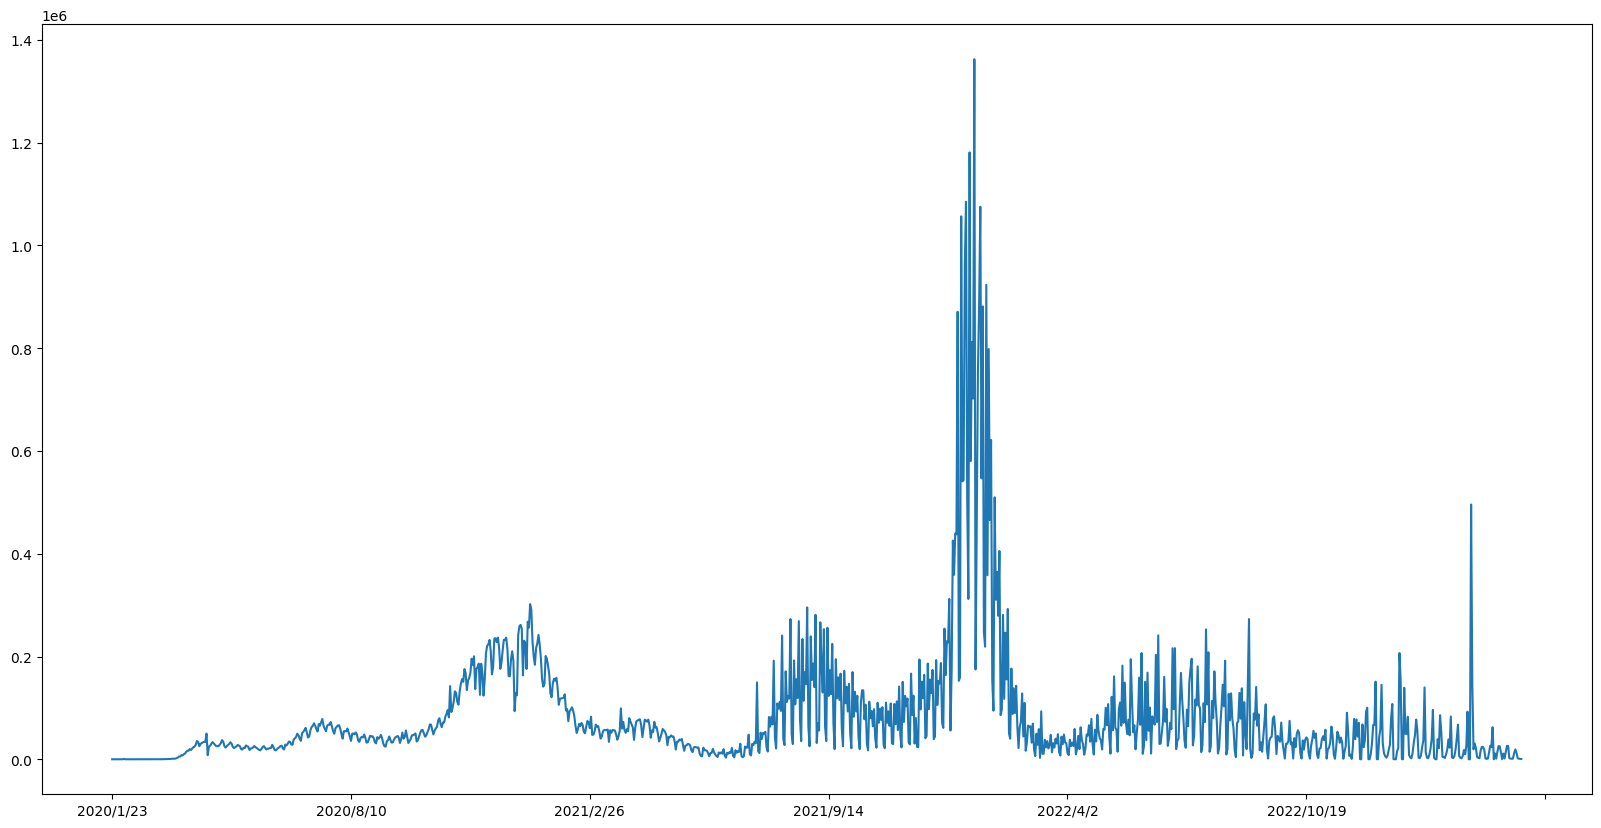

In [7]:
all_cases['daily'].plot(figsize=(20, 10))

<AxesSubplot: >

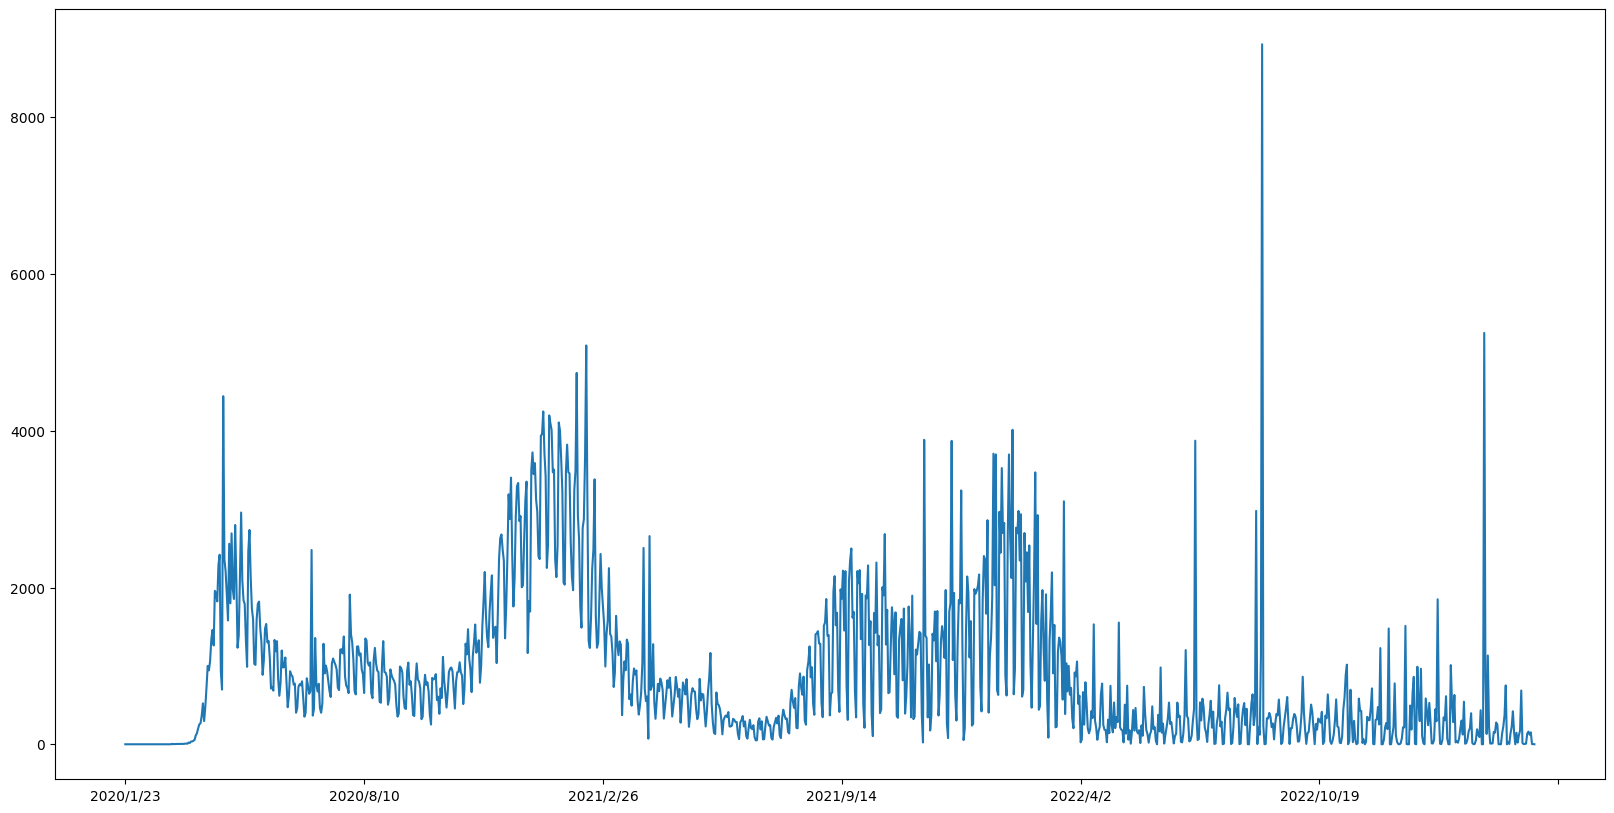

In [8]:
all_deaths['daily'].plot(figsize=(20, 10))

In [9]:
all_cases.head()

,sum,daily
2020/1/23,734.0,11.0
2020/1/24,741.0,7.0
2020/1/25,751.0,10.0
2020/1/26,759.0,8.0
2020/1/27,769.0,10.0


### May seperate the covid into 3 period according to 
https://www.thelancet.com/journals/laninf/article/PIIS1473-3099(22)00320-6/fulltext
1. before Jan 2021, the first COVID-19 vaccine wasn't delivered outside of a clinical trial setting
2. Jan 2021-Jan 2022, more than half population have received at least one dose of a COVID-19 vaccine
3. after Jan 2022

#### see the medians, might use median in one period I think

In [10]:
# print(all_cases['daily'].idxmax())
# all_cases['daily'].max()


for row in all_cases['daily']:
    p1_df = all_cases[all_cases.index.values< '2021/01/01']
    p1_med = p1_df['daily'].median()
print(p1_med)
print('date around median1: ',p1_df.daily[p1_df.daily>=p1_med].idxmin())
print('date around median2: ',p1_df.daily[p1_df.daily<p1_med].idxmax())
print(p1_df[p1_df.index.values=='2020/9/12'])
print(p1_df[p1_df.index.values=='2020/6/23'])
p1_df

37996.0
date around median1:  2020/6/23
date around median2:  2020/9/12
                 sum    daily
2020/9/12  6417247.0  37732.0
                 sum    daily
2020/6/23  2371116.0  38260.0


,sum,daily
2020/1/23,734.0,11.0
2020/1/24,741.0,7.0
2020/1/25,751.0,10.0
2020/1/26,759.0,8.0
2020/1/27,769.0,10.0
...,...,...
2020/12/27,18867474.0,124648.0
2020/12/28,19109473.0,241999.0
2020/12/29,19368312.0,258839.0
2020/12/30,19629724.0,261412.0


In [11]:
for row in all_cases['daily']:
    p2_df = all_cases[all_cases.index.values <'2022/01/01']
    p2_df = p2_df[p2_df.index.values>= '2021/01/01']
    p2_med = p2_df['daily'].median()
print(p2_med)
print('date around median1: ',p2_df.daily[p2_df.daily>=p2_med].idxmin())
print('date around median2: ',p2_df.daily[p2_df.daily<p2_med].idxmax())
print(p2_df[p2_df.index.values=='2021/11/4'])
print(p2_df[p2_df.index.values=='2021/2/18'])
p2_df

64989.0
date around median1:  2021/11/4
date around median2:  2021/2/18
                  sum    daily
2021/11/4  45161773.0  64989.0
                  sum    daily
2021/2/18  27458587.0  64736.0


,sum,daily
2021/1/1,20047314.0,163324.0
2021/1/2,20278065.0,230751.0
2021/1/3,20503589.0,225524.0
2021/1/4,20679372.0,175783.0
2021/1/5,20947104.0,267732.0
...,...,...
2021/12/27,51450598.0,425580.0
2021/12/28,51809760.0,359162.0
2021/12/29,52249214.0,439454.0
2021/12/30,52686928.0,437714.0


In [12]:
for row in all_cases['daily']:
    p3_df = all_cases[all_cases.index.values>= '2022/01/01']
    p3_med = p3_df['daily'].median()
print(p3_med)

print('date around median1: ',p3_df.daily[p3_df.daily>=p3_med].idxmin())
print('date around median2: ',p3_df.daily[p3_df.daily<p3_med].idxmax())
print(p3_df[p3_df.index.values=='2022/10/9'])
print(p3_df[p3_df.index.values=='2022/4/29'])
p3_df

40966.0
date around median1:  2022/10/9
date around median2:  2022/4/29
                  sum    daily
2022/10/9  90747702.0  41032.0
                  sum    daily
2022/4/29  78790406.0  40900.0


,sum,daily
2022/1/1,53710526.0,152715.0
2022/1/2,53869825.0,159299.0
2022/1/3,54926383.0,1056558.0
2022/1/4,55467399.0,541016.0
2022/1/5,56010638.0,543239.0
...,...,...
2023/4/13,96919577.0,12617.0
2023/4/14,96921668.0,2091.0
2023/4/15,96922761.0,1093.0
2023/4/16,96923507.0,746.0


### ANOVA test, to see if there is significant difference between three groups

In [13]:
# pick rows for periods to make them 
# sample_num = min(len(p1_df),len(p2_df),len(p3_df))

# p1_df_sample = p1_df.sample(n=sample_num)
# p2_df_sample = p2_df.sample(n=sample_num)
# p3_df_sample = p3_df.sample(n=sample_num)
# p1_df_sample.reset_index().drop(columns=['sum','index'],inplace = True)
# p2_df_sample.reset_index().drop(columns=['sum','index'],inplace = True)
# p3_df_sample.reset_index().drop(columns=['sum','index'],inplace = True)

p1_df_sample = p1_df.reset_index().drop(columns=['sum','index'])
p2_df_sample = p2_df.reset_index().drop(columns=['sum','index'])
p3_df_sample = p3_df.reset_index().drop(columns=['sum','index'])


In [14]:
p1_df_sample.rename(columns={'daily':'p1d'},inplace = True)
p2_df_sample.rename(columns={'daily':'p2d'},inplace = True)
p3_df_sample.rename(columns={'daily':'p3d'},inplace = True)

In [15]:
p1_df_sample

,p1d
0,11.0
1,7.0
2,10.0
3,8.0
4,10.0
...,...
339,124648.0
340,241999.0
341,258839.0
342,261412.0


In [16]:
df_anova = pd.concat([p1_df_sample,p2_df_sample,p3_df_sample],axis=1) 
df_anova

,p1d,p2d,p3d
0,11.0,163324.0,152715.0
1,7.0,230751.0,159299.0
2,10.0,225524.0,1056558.0
3,8.0,175783.0,541016.0
4,10.0,267732.0,543239.0
...,...,...,...
467,NaN,NaN,12617.0
468,NaN,NaN,2091.0
469,NaN,NaN,1093.0
470,NaN,NaN,746.0


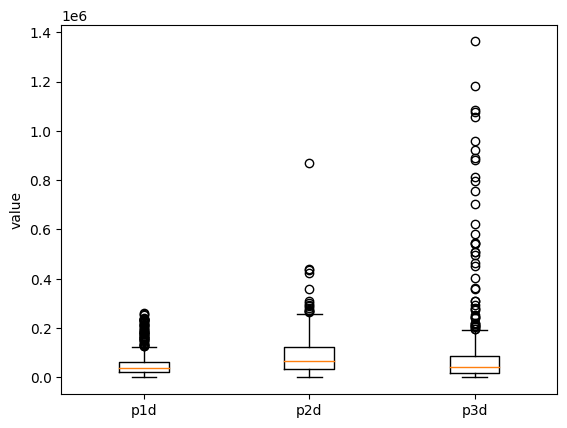

In [17]:
# # reshape the d dataframe suitable for statsmodels package 
df_melt = pd.melt(df_anova.reset_index(), id_vars=['index'], value_vars=['p1d', 'p2d', 'p3d'])
# # replace column names
df_melt.columns = ['index', 'periods', 'value']

# generate a boxplot to see the data distribution by treatments. Using boxplot, we can 
# easily detect the differences between different treatments
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)
# ax.boxplot([df_anova.p1d, df_anova.p2d, df_anova.p3d])
ax.boxplot([p1_df_sample.p1d, p2_df_sample.p2d, p3_df_sample.p3d])
ax.set_xticklabels(["p1d", "p2d", "p3d"]) 
ax.set_ylabel("value") 
plt.show()

In [18]:
import scipy.stats as stats
# stats f_oneway functions takes the groups as input and returns ANOVA F and p value
# fvalue, pvalue = stats.f_oneway(df_anova['p1d'], df_anova['p2d'], df_anova['p3d'])
fvalue, pvalue = stats.f_oneway(p1_df_sample.p1d, p2_df_sample.p2d, p3_df_sample.p3d)
print(fvalue, pvalue)
# 9.638427379292114 7.046352059594926e-05

# get ANOVA table as R like output
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Ordinary Least Squares (OLS) model
model = ols('value ~ C(periods)', data=df_melt).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

nan nan


,sum_sq,df,F,PR(>F)
C(periods),3.027690e+11,2.0,9.638427,0.00007
Residual,1.850208e+13,1178.0,NaN,NaN


In [19]:
# ANOVA posthoc_tukey
from scipy.stats import tukey_hsd
res = tukey_hsd(df_anova.p1d, df_anova.p2d, df_anova.p3d)
print(res)

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)        nan       nan       nan       nan
 (0 - 2)        nan       nan       nan       nan
 (1 - 0)        nan       nan       nan       nan
 (1 - 2)        nan       nan       nan       nan
 (2 - 0)        nan       nan       nan       nan
 (2 - 1)        nan       nan       nan       nan



### It shows period 2 and 3 aren't significantly different

In [8]:
all_deaths['rate'] = all_deaths['daily'] / all_cases['daily']

<AxesSubplot: >

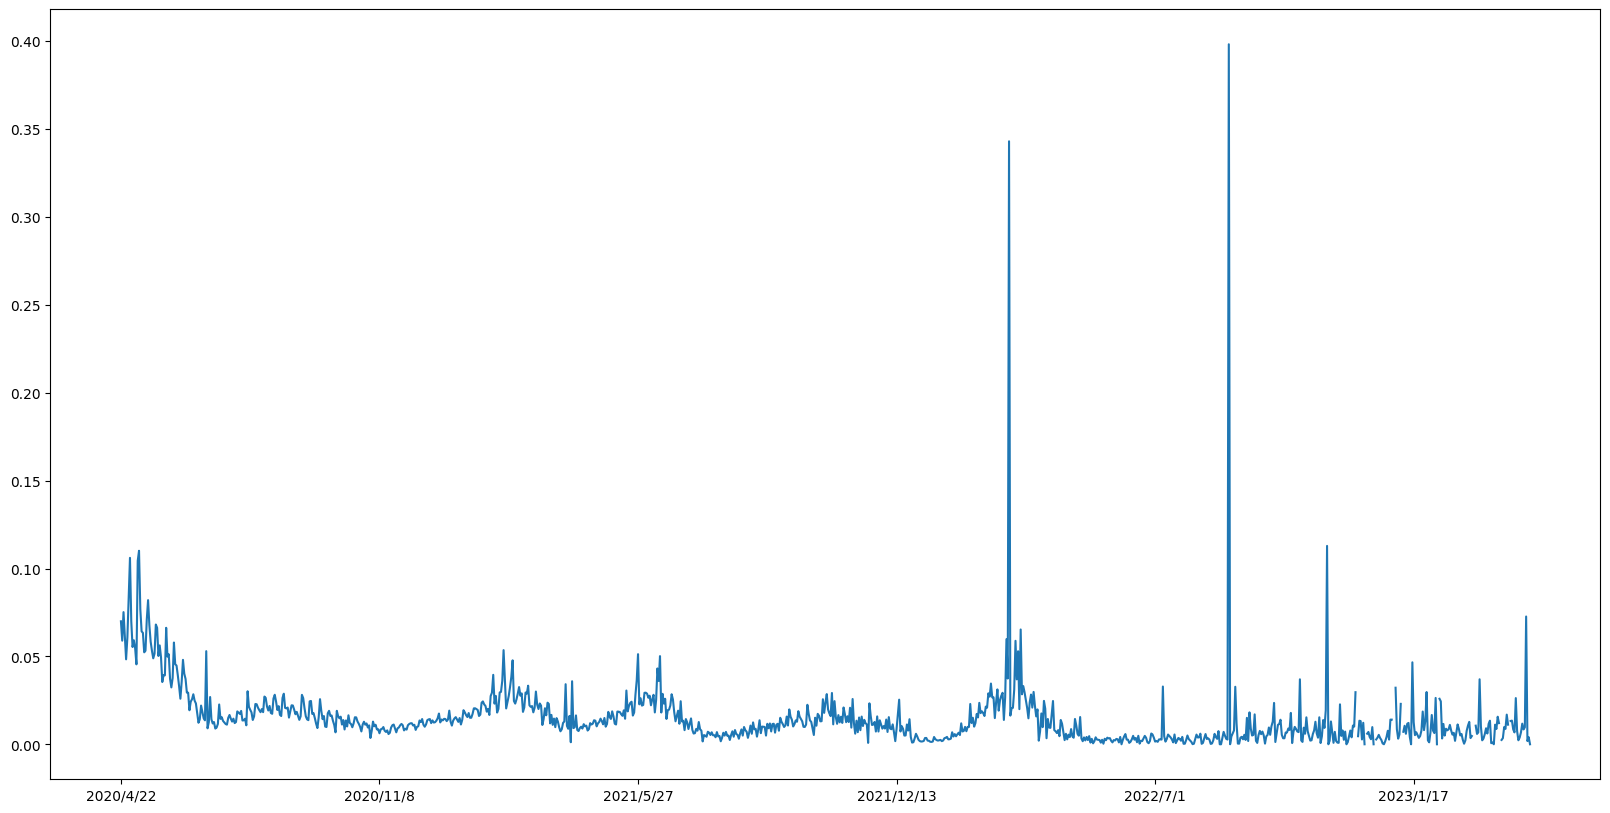

In [9]:
all_deaths['rate'][90:].plot(figsize=(20, 10))

In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import BayesianRidge, LinearRegression, ElasticNet
from sklearn.model_selection import cross_val_score    # 交叉验证
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
data = pd.read_csv("C:/Users/TANTAN/Desktop/df_main.csv")
data_df = pd.DataFrame(data)

In [5]:
data_df.head()

,Unnamed: 0,fips,Staffed_Beds,Total_Discharges,Patient_Days,Gross_Patient_Revenue,Hospitals,Local_Hospital,ADI_NATRANK,ADI_STATERNK,...,pct_veterans_male,pop_adult_education_bachelors_or_higher,pop_adult_education_high_school,pop_adult_education_less_than_high_school,pop_adult_education_some_college_or_associates,pop_lived_in_same_house_last_year,pop_total,pop_veterans,pop_veterans_female,pop_veterans_male
0,0,1001,77.0,3049.0,15984.0,250284.0,1.0,yes,66.977778,4.355556,...,88.111428,8464,8819,2886,9201,48039.0,55639,4559,542,4017
1,1,1003,301.0,18080.0,78361.0,2481966.0,3.0,yes,51.534483,2.655172,...,91.796182,36513,29636,10250,34448,191350.0,218289,19174,1573,17601
2,2,1005,47.0,1055.0,4571.0,76099.0,1.0,yes,90.900000,7.950000,...,92.014925,1409,4525,3131,3955,20996.0,25026,1340,107,1233
3,3,1007,156.0,229.0,1053.0,31288.0,1.0,yes,83.411765,6.647059,...,94.771783,1388,5442,2189,3292,19347.0,22374,1205,63,1142
4,4,1009,0.0,0.0,0.0,0.0,0.0,no,72.325581,4.906977,...,93.603286,4158,9757,4494,11023,52428.0,57755,3408,218,3190


In [7]:
data.isnull().sum() #checking for total null values

Unnamed: 0                           0
fips                                 0
Staffed_Beds                         0
Total_Discharges                     0
Patient_Days                         0
                                    ..
pop_lived_in_same_house_last_year    0
pop_total                            0
pop_veterans                         0
pop_veterans_female                  0
pop_veterans_male                    0
Length: 372, dtype: int64

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3124 entries, 0 to 3123
Columns: 372 entries, Unnamed: 0 to pop_veterans_male
dtypes: float64(199), int64(169), object(4)
memory usage: 8.9+ MB


In [10]:
# sns.set(style='whitegrid',context='notebook')
# sns.pairplot(data_df, height=2,diag_kind='kde')

C:\Users\TANTAN\AppData\Local\Temp\ipykernel_4504\155695204.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = data_df.corr()


(368.5, -0.5)

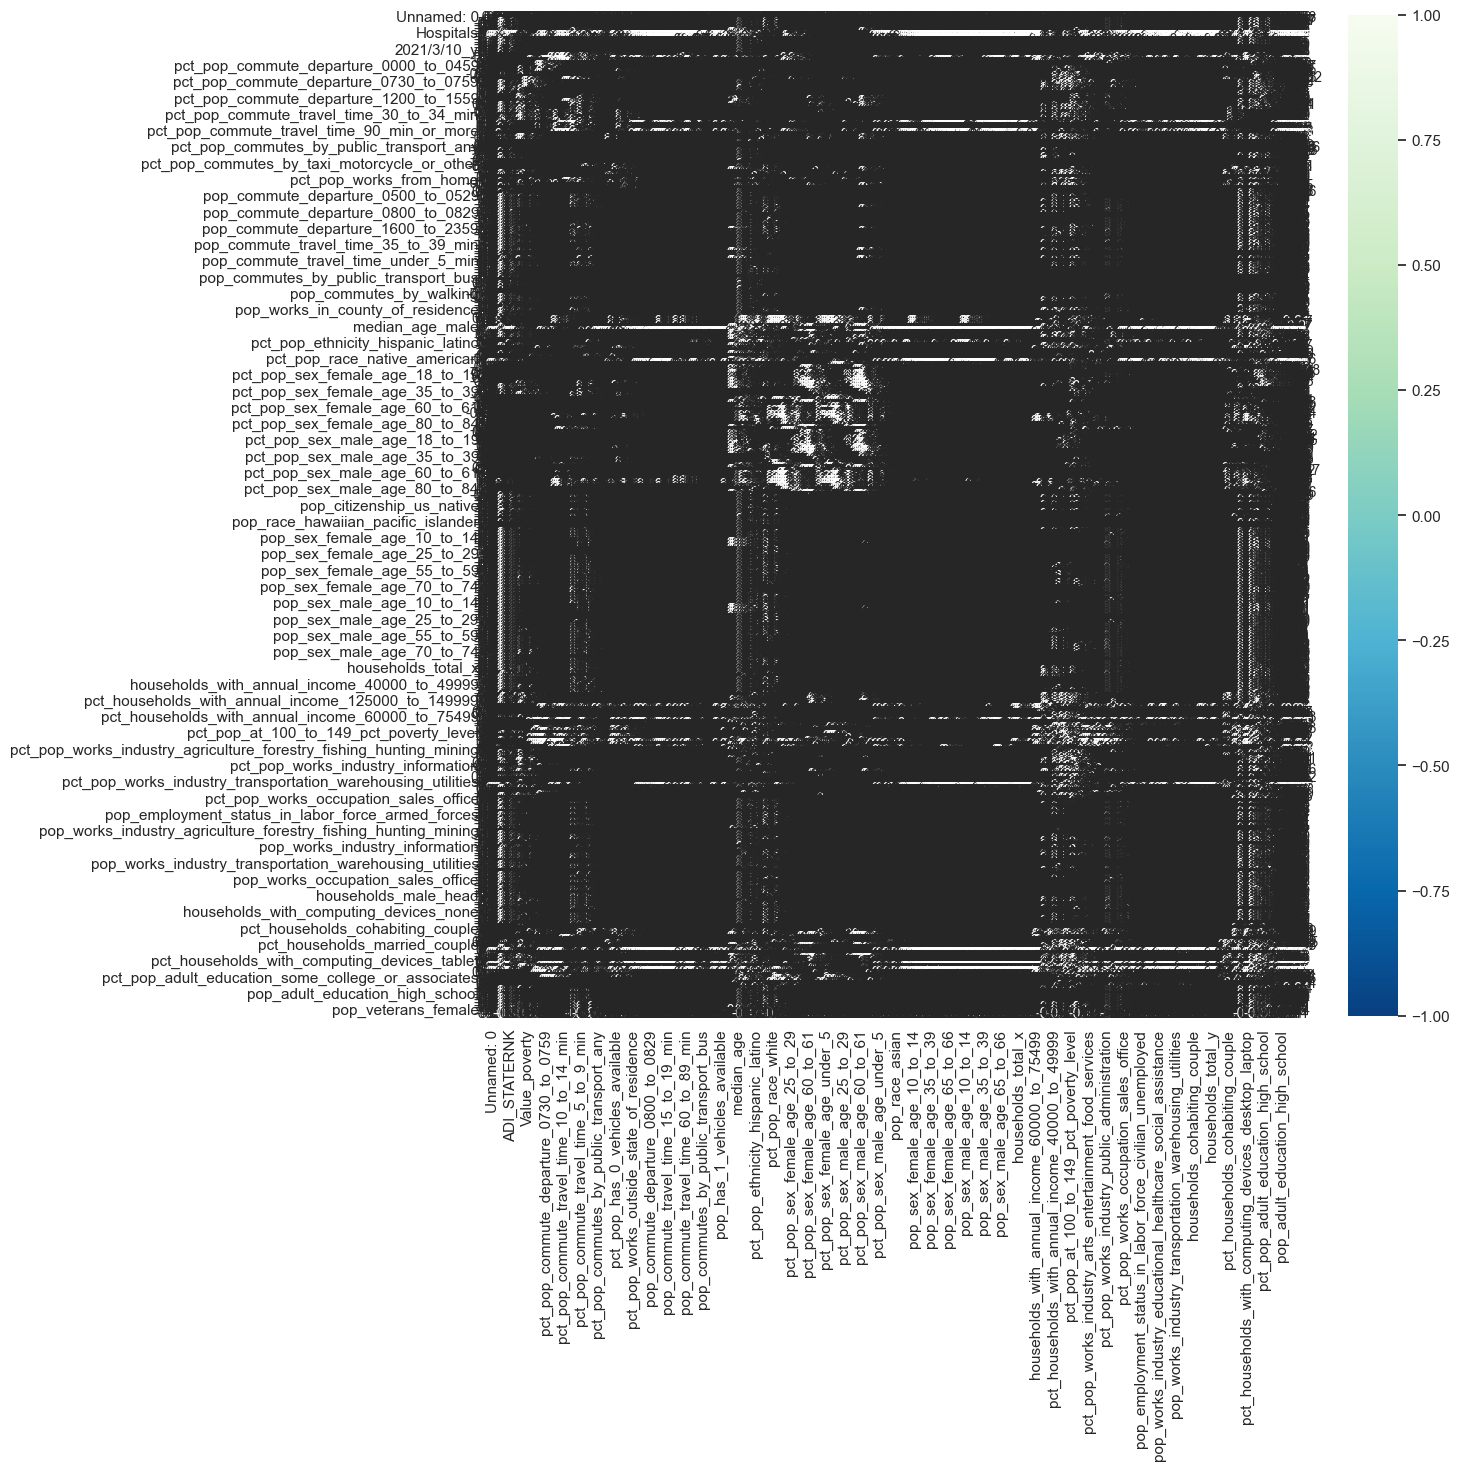

In [11]:
# 相关度
corr = data_df.corr()
plt.figure(figsize=(13, 13))   # 300*300即为3,3；1000*1000即为10,10
ax = sns.heatmap(corr, cmap='GnBu_r', square=False, annot=True, annot_kws={'size':10})
bottom, top = ax.get_ylim()
ax.set_ylim(bottom+0.5, top - 0.5)

In [ ]:
from sklearn.feature_selection import mutual_info_classif
# determine the mutual information
mutual_info = mutual_info_classif(X_train, y_train)
# mutual_info
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending=False)

In [ ]:
mutual_info.sort_values(ascending=False).plot.bar(figsize=(20, 8))

In [ ]:
feature2=df[[xxxx]]

y1=df[xxx]

# Create the RFE object and compute a cross-validated score.
lr = LinearRegression()
# regression   https://blog.csdn.net/qq_36327687/article/details/85008414    https://www.jianshu.com/p/025395835591
rfecv = RFECV(estimator=lr,          
              step=1,               # drop how many features for a step 
              cv=KFold(5),      
              scoring='neg_mean_squared_error',     
              verbose = 0,     
              n_jobs = 1
              )
X_RFECV = rfecv.fit_transform(feature2,y1)
print("RFECV fs——————————————————————————————————————————————————")
print("Optimal number of features : %d" % rfecv.n_features_)
print("Ranking of features : %s" % list(rfecv.ranking_))


# Plot number of features VS. cross-validation scores
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (nb of correct classifications)")
plt.plot(range(1, len(rfecv.grid_scores_) + 1), rfecv.grid_scores_)
plt.show()